# Генеративные модели: VAE и GAN на MNIST

Разберем две классические генеративные архитектуры:

1. **VAE** — Variational Autoencoder, вариационный автоэнкодер.
2. **GAN** — Generative Adversarial Network, генеративно-состязательная сеть.

Данные: `ylecun/mnist` с Hugging Face.

Фреймворк: `TensorFlow / Keras`.

## План занятия

| Этап | Содержание |
|---|---|
| 1 | Идея генеративного моделирования |
| 2 | Загрузка MNIST с Hugging Face |
| 3 | VAE: encoder, sampling, decoder |
| 4 | Обучение VAE и генерация цифр |
| 5 | GAN: generator и discriminator |
| 6 | Обучение GAN и сравнение подходов |

Генеративная модель пытается выучить распределение данных:

$$
p_{\mathrm{data}}(x).
$$

После обучения она должна уметь создавать новые объекты:

$$
x_{\mathrm{new}} \sim p_\theta(x).
$$

## 1. Установка и импорт библиотек

Если зависимости уже установлены, первая ячейка выполнится быстро.

In [ ]:
%pip install -q tensorflow datasets matplotlib pandas numpy pillow

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from datasets import load_dataset


SEED = 42
DATASET_NAME = "ylecun/mnist"


def set_global_seed(seed):
    """
    Фиксирует генераторы случайных чисел.

    Аргументы:
        seed: целое число для инициализации генераторов.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_global_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1780044702.666362   11472 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780044702.702365   11472 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780044704.010067   11472 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1780044705.606692   11472 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Загрузка MNIST с Hugging Face

MNIST состоит из черно-белых изображений рукописных цифр размером `28 x 28`.

Метки классов в этом блокноте нужны только для просмотра данных. VAE и GAN обучаются без меток.

In [2]:
dataset = load_dataset(DATASET_NAME)
dataset

README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [3]:
print(dataset["train"].features)
print("Train:", len(dataset["train"]))
print("Test:", len(dataset["test"]))

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])}
Train: 60000
Test: 10000


## 3. Подготовка данных

Для ускорения демонстрации возьмем подмножество обучающей выборки. При желании можно увеличить `TRAIN_LIMIT`.

Для VAE будем использовать пиксели в диапазоне `[0, 1]`.

Для GAN удобнее использовать диапазон `[-1, 1]`, потому что генератор заканчивается активацией `tanh`.

In [4]:
IMAGE_SIZE = 28
IMAGE_DIM = IMAGE_SIZE * IMAGE_SIZE

TRAIN_LIMIT = 20000
TEST_LIMIT = 5000

BATCH_SIZE = 256


def dataset_to_numpy(dataset_split, limit=None):
    """
    Преобразует split Hugging Face Dataset в numpy-массив изображений и меток.

    Аргументы:
        dataset_split: split датасета, например dataset["train"].
        limit: сколько объектов взять. Если None, используются все объекты.

    Возвращает:
        images: массив формы (N, 28, 28), значения в диапазоне [0, 1].
        labels: массив меток цифр.
    """
    if limit is None:
        limit = len(dataset_split)

    images = []
    labels = []

    for item in dataset_split.select(range(limit)):
        image = item["image"].convert("L")
        image = np.asarray(image, dtype="float32") / 255.0
        images.append(image)
        labels.append(item["label"])

    return np.asarray(images, dtype="float32"), np.asarray(labels, dtype="int32")


x_train, y_train = dataset_to_numpy(dataset["train"], TRAIN_LIMIT)
x_test, y_test = dataset_to_numpy(dataset["test"], TEST_LIMIT)

x_train_flat = x_train.reshape(-1, IMAGE_DIM)
x_test_flat = x_test.reshape(-1, IMAGE_DIM)

x_train_gan = x_train_flat * 2.0 - 1.0

print("VAE train:", x_train_flat.shape)
print("GAN train:", x_train_gan.shape)

VAE train: (20000, 784)
GAN train: (20000, 784)


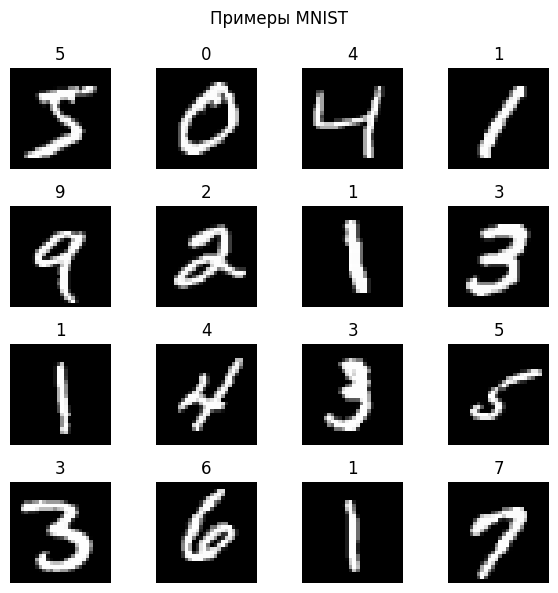

In [5]:
def show_images(images, labels=None, title="", n=16, value_range=(0, 1)):
    """
    Показывает сетку изображений.

    Аргументы:
        images: массив изображений формы (N, 28, 28) или (N, 784).
        labels: необязательные подписи.
        title: заголовок рисунка.
        n: количество изображений.
        value_range: диапазон значений пикселей для imshow.
    """
    if images.ndim == 2:
        images = images.reshape(-1, 28, 28)

    plt.figure(figsize=(6, 6))

    for i in range(n):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i], cmap="gray", vmin=value_range[0], vmax=value_range[1])
        if labels is not None:
            plt.title(str(labels[i]))
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_images(x_train, y_train, title="Примеры MNIST")

In [6]:
vae_train_ds = (
    tf.data.Dataset.from_tensor_slices(x_train_flat)
    .shuffle(TRAIN_LIMIT, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

vae_test_ds = (
    tf.data.Dataset.from_tensor_slices(x_test_flat)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

gan_train_ds = (
    tf.data.Dataset.from_tensor_slices(x_train_gan)
    .shuffle(TRAIN_LIMIT, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

W0000 00:00:1780044720.061646   11472 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1780044720.275884   11472 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12883 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:02:00.0, compute capability: 12.0a


# Часть A. Variational Autoencoder

Обычный автоэнкодер кодирует объект в точку:

$$
z = f_\theta(x).
$$

VAE кодирует объект в параметры распределения:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu(x), \sigma^2(x)).
$$

Затем мы сэмплируем:

$$
z = \mu + \sigma \odot \epsilon,\quad \epsilon \sim \mathcal{N}(0, I).
$$

Функция потерь VAE состоит из двух частей:

$$
\mathcal{L} = \mathcal{L}_{\mathrm{reconstruction}} + \mathcal{L}_{\mathrm{KL}}.
$$

KL-компонента приближает латентное распределение к стандартному нормальному:

$$
D_{KL}(q_\phi(z \mid x) \Vert p(z)).
$$

In [7]:
LATENT_DIM = 2


def sampling(args):
    """
    Реализация reparameterization trick.

    Аргументы:
        args: кортеж из двух тензоров: z_mean и z_log_var.

    Возвращает:
        Сэмпл z из нормального распределения с параметрами encoder.
    """
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def build_vae_encoder(latent_dim):
    """
    Строит encoder для VAE.

    Аргументы:
        latent_dim: размерность латентного пространства.

    Возвращает:
        Keras-модель, которая возвращает z_mean, z_log_var и z.
    """
    encoder_input = keras.Input(shape=(IMAGE_DIM,), name="encoder_input")
    x = layers.Dense(256, activation="relu", name="encoder_dense_1")(encoder_input)
    x = layers.Dense(128, activation="relu", name="encoder_dense_2")(x)

    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

    return keras.Model(encoder_input, [z_mean, z_log_var, z], name="vae_encoder")


def build_vae_decoder(latent_dim):
    """
    Строит decoder для VAE.

    Аргументы:
        latent_dim: размерность входного латентного вектора.

    Возвращает:
        Keras-модель, которая восстанавливает изображение из z.
    """
    decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(128, activation="relu", name="decoder_dense_1")(decoder_input)
    x = layers.Dense(256, activation="relu", name="decoder_dense_2")(x)
    decoder_output = layers.Dense(IMAGE_DIM, activation="sigmoid", name="decoder_output")(x)

    return keras.Model(decoder_input, decoder_output, name="vae_decoder")


vae_encoder = build_vae_encoder(LATENT_DIM)
vae_decoder = build_vae_decoder(LATENT_DIM)

vae_encoder.summary()
vae_decoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_1     │ (None, 256)       │    200,960 │ encoder_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_2     │ (None, 128)       │     32,896 │ encoder_dense_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ encoder_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ encoder_dense_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
def train_vae(encoder, decoder, train_ds, test_ds, epochs=20, learning_rate=1e-3):
    """
    Обучает VAE через простой training loop.

    Аргументы:
        encoder: модель encoder.
        decoder: модель decoder.
        train_ds: обучающий tf.data.Dataset.
        test_ds: validation tf.data.Dataset.
        epochs: количество эпох.
        learning_rate: скорость обучения.

    Возвращает:
        DataFrame с историей loss.
    """
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    history = []

    for epoch in range(1, epochs + 1):
        train_losses = []

        for x_batch in train_ds:
            with tf.GradientTape() as tape:
                z_mean, z_log_var, z = encoder(x_batch, training=True)
                reconstruction = decoder(z, training=True)

                reconstruction_loss = keras.losses.binary_crossentropy(x_batch, reconstruction)
                reconstruction_loss = tf.reduce_mean(reconstruction_loss * IMAGE_DIM)

                kl_loss = -0.5 * tf.reduce_sum(
                    1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1,
                )
                kl_loss = tf.reduce_mean(kl_loss)

                total_loss = reconstruction_loss + kl_loss

            gradients = tape.gradient(total_loss, encoder.trainable_weights + decoder.trainable_weights)
            optimizer.apply_gradients(zip(gradients, encoder.trainable_weights + decoder.trainable_weights))
            train_losses.append(float(total_loss))

        val_losses = []
        for x_batch in test_ds:
            z_mean, z_log_var, z = encoder(x_batch, training=False)
            reconstruction = decoder(z, training=False)
            reconstruction_loss = keras.losses.binary_crossentropy(x_batch, reconstruction)
            reconstruction_loss = tf.reduce_mean(reconstruction_loss * IMAGE_DIM)
            kl_loss = -0.5 * tf.reduce_sum(
                1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1,
            )
            kl_loss = tf.reduce_mean(kl_loss)
            val_losses.append(float(reconstruction_loss + kl_loss))

        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(np.mean(val_losses)),
        }
        history.append(row)
        print(f"Epoch {epoch:02d}: train_loss={row['train_loss']:.3f}, val_loss={row['val_loss']:.3f}")

    return pd.DataFrame(history)

Epoch 01: train_loss=260.455, val_loss=195.627
Epoch 02: train_loss=193.886, val_loss=181.589
Epoch 03: train_loss=182.640, val_loss=173.414
Epoch 04: train_loss=175.817, val_loss=169.859
Epoch 05: train_loss=172.704, val_loss=168.265
Epoch 06: train_loss=170.612, val_loss=166.632
Epoch 07: train_loss=168.729, val_loss=165.066
Epoch 08: train_loss=167.419, val_loss=164.109
Epoch 09: train_loss=166.125, val_loss=162.891
Epoch 10: train_loss=164.968, val_loss=161.884
Epoch 11: train_loss=164.028, val_loss=161.233
Epoch 12: train_loss=162.916, val_loss=160.384
Epoch 13: train_loss=162.103, val_loss=159.673
Epoch 14: train_loss=161.306, val_loss=159.139
Epoch 15: train_loss=160.292, val_loss=158.752
Epoch 16: train_loss=159.816, val_loss=157.838
Epoch 17: train_loss=159.331, val_loss=157.998
Epoch 18: train_loss=158.781, val_loss=157.264
Epoch 19: train_loss=158.405, val_loss=156.920
Epoch 20: train_loss=157.529, val_loss=156.531


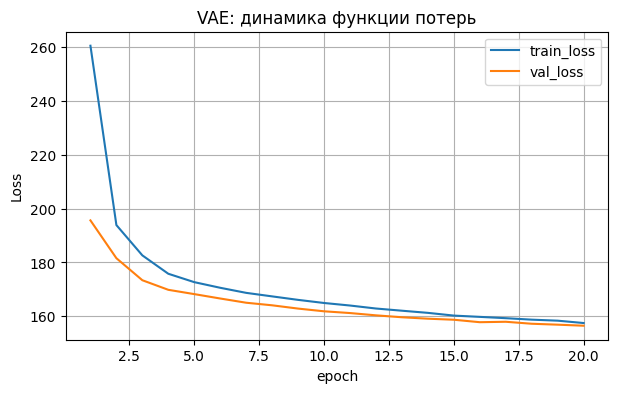

In [9]:
vae_history = train_vae(
    vae_encoder,
    vae_decoder,
    vae_train_ds,
    vae_test_ds,
    epochs=20,
    learning_rate=1e-3,
)

vae_history.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(7, 4), grid=True)
plt.title("VAE: динамика функции потерь")
plt.ylabel("Loss")
plt.show()

I0000 00:00:1780044785.403853   11636 service.cc:153] XLA service 0x7acd3802d6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780044785.403873   11636 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1780044785.408366   11636 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780044785.424561   11636 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1780044785.431696   11636 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1053937__.1
I0000 00:00:1780044873.068528   11636 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


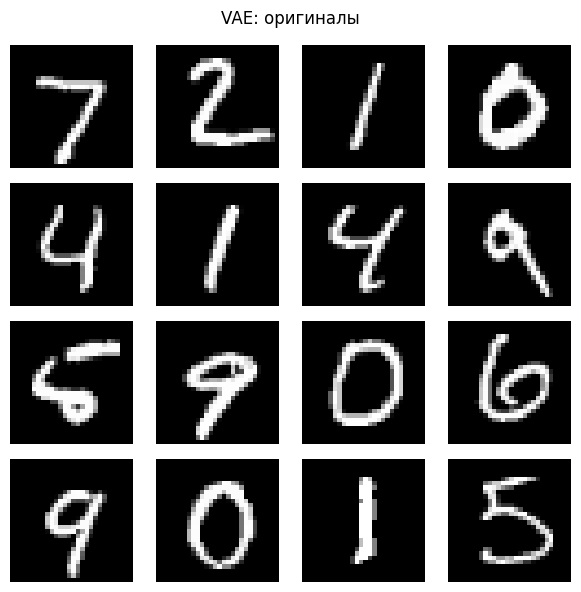

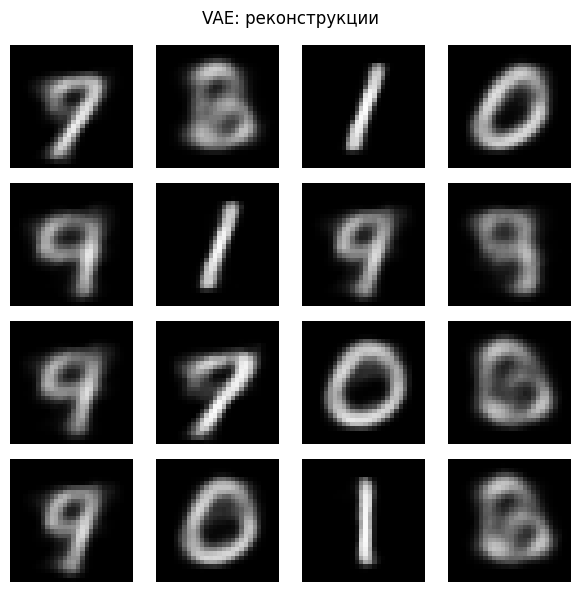

In [10]:
z_mean, z_log_var, z = vae_encoder.predict(x_test_flat[:16], verbose=0)
vae_reconstructed = vae_decoder.predict(z, verbose=0)

show_images(x_test_flat[:16], title="VAE: оригиналы")
show_images(vae_reconstructed, title="VAE: реконструкции")

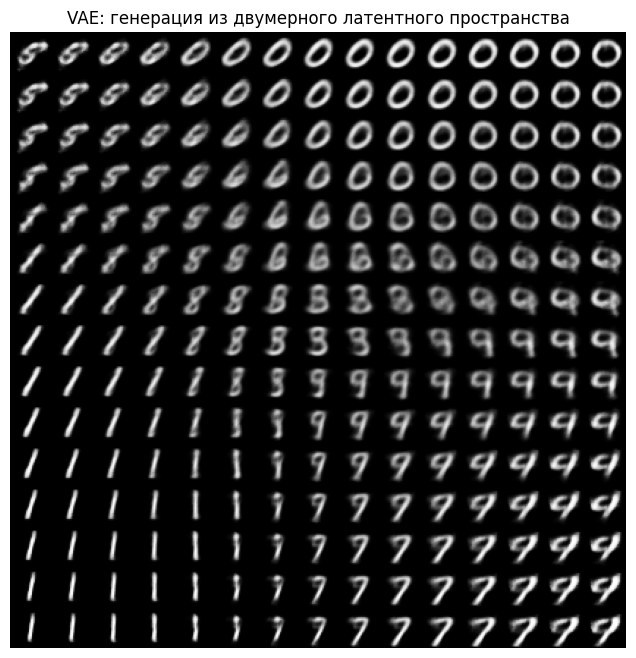

In [11]:
def generate_vae_grid(decoder, grid_size=15, value_range=(-3, 3)):
    """
    Генерирует сетку изображений из двумерного латентного пространства VAE.

    Аргументы:
        decoder: обученный decoder.
        grid_size: размер сетки.
        value_range: диапазон значений для координат z.
    """
    grid_x = np.linspace(value_range[0], value_range[1], grid_size)
    grid_y = np.linspace(value_range[1], value_range[0], grid_size)

    canvas = np.zeros((grid_size * 28, grid_size * 28))

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]], dtype="float32")
            generated = decoder.predict(z_sample, verbose=0)[0].reshape(28, 28)
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = generated

    plt.figure(figsize=(8, 8))
    plt.imshow(canvas, cmap="gray")
    plt.axis("off")
    plt.title("VAE: генерация из двумерного латентного пространства")
    plt.show()


generate_vae_grid(vae_decoder)

# Часть B. Generative Adversarial Network

GAN состоит из двух сетей:

- **Generator** создает изображение из случайного шума:

$$
G(z) \rightarrow x_{\mathrm{fake}}.
$$

- **Discriminator** пытается отличить реальные изображения от сгенерированных:

$$
D(x) \rightarrow [0, 1].
$$

Обучение идет как игра:

$$
\min_G \max_D
\mathbb{E}_{x \sim p_{\mathrm{data}}}[\log D(x)] +
\mathbb{E}_{z \sim p(z)}[\log(1 - D(G(z)))].
$$

На практике GAN может обучаться нестабильно, поэтому ниже используется простая архитектура и небольшой learning rate.

In [12]:
NOISE_DIM = 64


def build_generator(noise_dim):
    """
    Строит generator для GAN.

    Аргументы:
        noise_dim: размерность случайного входного вектора.

    Возвращает:
        Keras-модель noise -> image.
    """
    noise_input = keras.Input(shape=(noise_dim,), name="noise_input")
    x = layers.Dense(128, activation="relu", name="generator_dense_1")(noise_input)
    x = layers.Dense(256, activation="relu", name="generator_dense_2")(x)
    x = layers.Dense(512, activation="relu", name="generator_dense_3")(x)
    image_output = layers.Dense(IMAGE_DIM, activation="tanh", name="generated_image")(x)

    return keras.Model(noise_input, image_output, name="gan_generator")


def build_discriminator():
    """
    Строит discriminator для GAN.

    Возвращает:
        Keras-модель image -> probability_real.
    """
    image_input = keras.Input(shape=(IMAGE_DIM,), name="image_input")
    x = layers.Dense(512, activation="leaky_relu", name="discriminator_dense_1")(image_input)
    x = layers.Dropout(0.3, name="discriminator_dropout_1")(x)
    x = layers.Dense(256, activation="leaky_relu", name="discriminator_dense_2")(x)
    x = layers.Dropout(0.3, name="discriminator_dropout_2")(x)
    probability_real = layers.Dense(1, activation="sigmoid", name="probability_real")(x)

    return keras.Model(image_input, probability_real, name="gan_discriminator")


generator = build_generator(NOISE_DIM)
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

Model: "gan_generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noise_input (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator_dense_1 (Dense)       │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator_dense_2 (Dense)       │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator_dense_3 (Dense)       │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generated_image (Dense)         │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,120 (2.19 MB)

 Trainable params: 575,120 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

Model: "gan_discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_dense_1 (Dense)   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_dropout_1         │ (None, 512)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_dense_2 (Dense)   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator_dropout_2         │ (None, 256)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probability_real (Dense)        │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def train_gan(generator, discriminator, train_ds, epochs=30, noise_dim=NOISE_DIM, learning_rate=2e-4):
    """
    Обучает GAN через простой training loop.

    Аргументы:
        generator: модель генератора.
        discriminator: модель дискриминатора.
        train_ds: tf.data.Dataset с реальными изображениями в диапазоне [-1, 1].
        epochs: количество эпох.
        noise_dim: размерность шума.
        learning_rate: скорость обучения.

    Возвращает:
        DataFrame с историей потерь generator и discriminator.
    """
    bce = keras.losses.BinaryCrossentropy()
    generator_optimizer = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5)
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5)

    history = []
    fixed_noise = tf.random.normal((16, noise_dim))

    for epoch in range(1, epochs + 1):
        d_losses = []
        g_losses = []

        for real_images in train_ds:
            batch_size = tf.shape(real_images)[0]
            noise = tf.random.normal((batch_size, noise_dim))

            with tf.GradientTape() as disc_tape:
                fake_images = generator(noise, training=True)

                real_output = discriminator(real_images, training=True)
                fake_output = discriminator(fake_images, training=True)

                real_loss = bce(tf.ones_like(real_output) * 0.9, real_output)
                fake_loss = bce(tf.zeros_like(fake_output), fake_output)
                discriminator_loss = real_loss + fake_loss

            disc_gradients = disc_tape.gradient(discriminator_loss, discriminator.trainable_weights)
            discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_weights))

            noise = tf.random.normal((batch_size, noise_dim))

            with tf.GradientTape() as gen_tape:
                fake_images = generator(noise, training=True)
                fake_output = discriminator(fake_images, training=False)
                generator_loss = bce(tf.ones_like(fake_output), fake_output)

            gen_gradients = gen_tape.gradient(generator_loss, generator.trainable_weights)
            generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_weights))

            d_losses.append(float(discriminator_loss))
            g_losses.append(float(generator_loss))

        row = {
            "epoch": epoch,
            "discriminator_loss": float(np.mean(d_losses)),
            "generator_loss": float(np.mean(g_losses)),
        }
        history.append(row)
        print(
            f"Epoch {epoch:02d}: "
            f"d_loss={row['discriminator_loss']:.3f}, "
            f"g_loss={row['generator_loss']:.3f}"
        )

        if epoch in [1, 5, 10, 20, epochs]:
            generated = generator.predict(fixed_noise, verbose=0)
            generated = (generated + 1.0) / 2.0
            show_images(generated, title=f"GAN: генерация после эпохи {epoch}")

    return pd.DataFrame(history)

Epoch 01: d_loss=1.095, g_loss=0.907


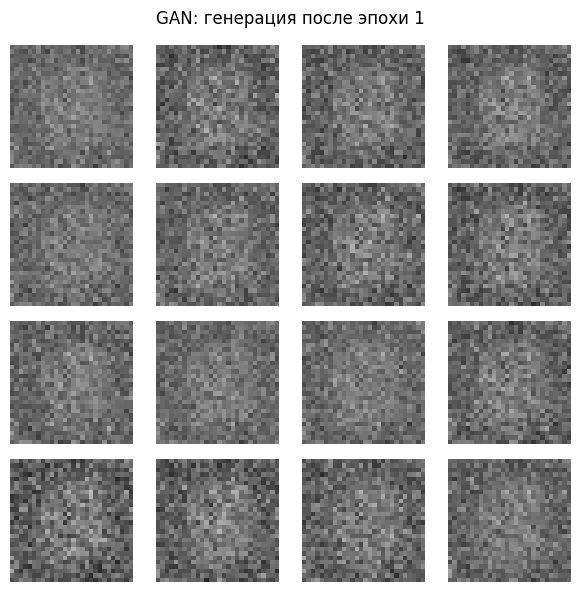

Epoch 02: d_loss=1.195, g_loss=0.897
Epoch 03: d_loss=1.043, g_loss=1.171
Epoch 04: d_loss=0.895, g_loss=1.443
Epoch 05: d_loss=0.792, g_loss=1.846


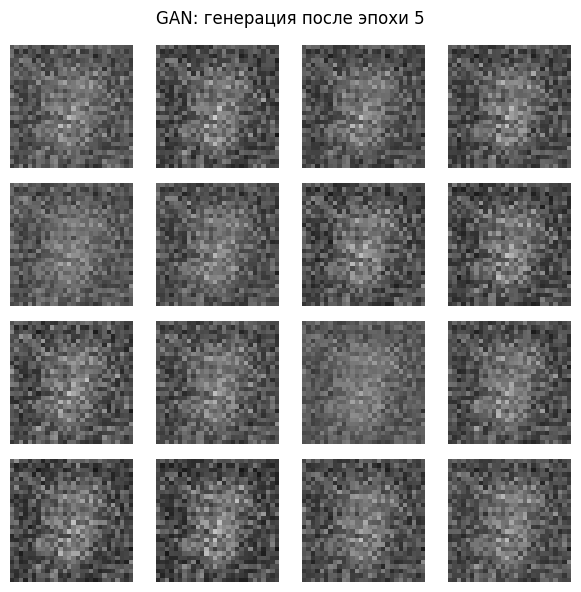

Epoch 06: d_loss=0.723, g_loss=2.259
Epoch 07: d_loss=0.698, g_loss=2.451
Epoch 08: d_loss=0.713, g_loss=2.675
Epoch 09: d_loss=0.731, g_loss=2.604
Epoch 10: d_loss=0.688, g_loss=2.944


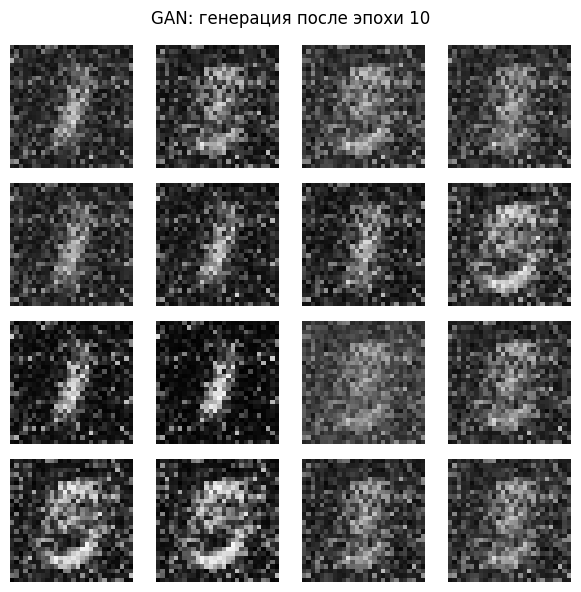

Epoch 11: d_loss=0.676, g_loss=2.986
Epoch 12: d_loss=0.680, g_loss=3.050
Epoch 13: d_loss=0.671, g_loss=3.013
Epoch 14: d_loss=0.709, g_loss=3.041
Epoch 15: d_loss=0.718, g_loss=2.792
Epoch 16: d_loss=0.750, g_loss=2.809
Epoch 17: d_loss=0.708, g_loss=3.162
Epoch 18: d_loss=0.682, g_loss=3.228
Epoch 19: d_loss=0.713, g_loss=3.033
Epoch 20: d_loss=0.734, g_loss=3.038


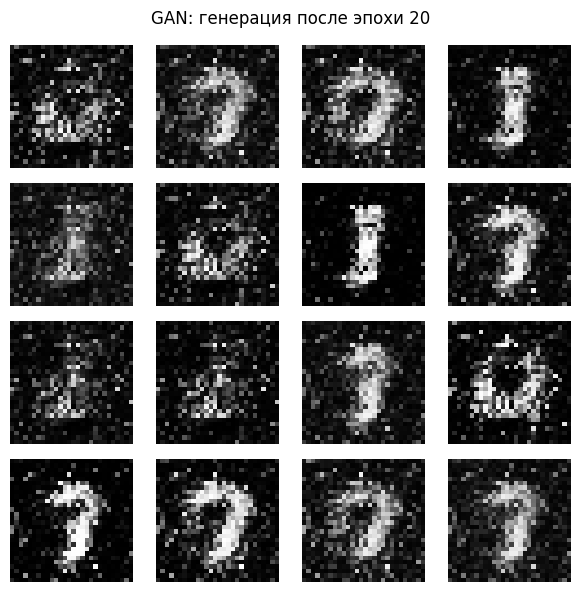

Epoch 21: d_loss=0.689, g_loss=3.158
Epoch 22: d_loss=0.711, g_loss=3.079
Epoch 23: d_loss=0.739, g_loss=2.831
Epoch 24: d_loss=0.723, g_loss=2.952
Epoch 25: d_loss=0.746, g_loss=2.663
Epoch 26: d_loss=0.714, g_loss=2.701
Epoch 27: d_loss=0.782, g_loss=2.624
Epoch 28: d_loss=0.802, g_loss=2.485
Epoch 29: d_loss=0.827, g_loss=2.412
Epoch 30: d_loss=0.774, g_loss=2.544


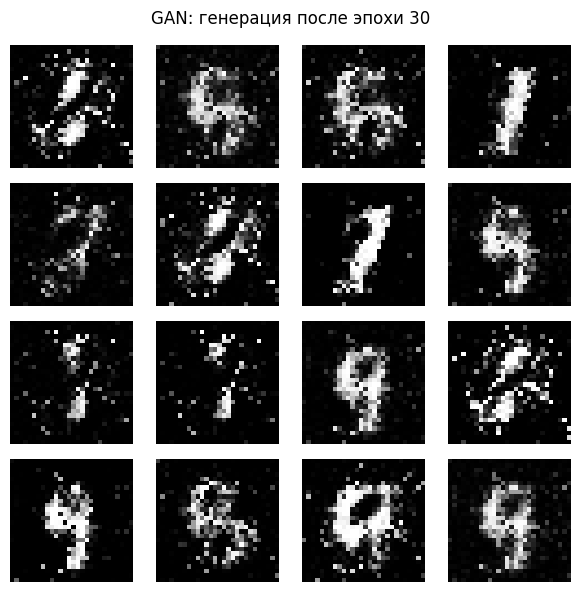

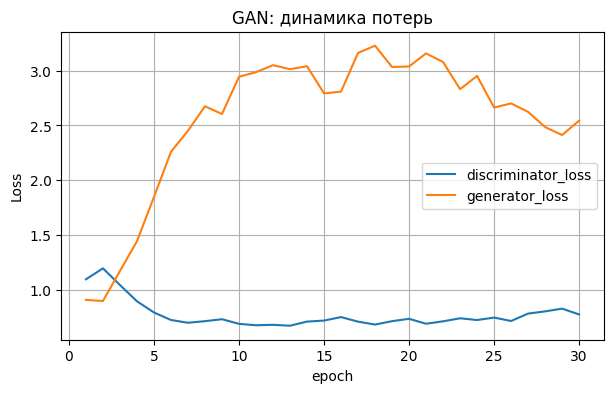

In [14]:
gan_history = train_gan(
    generator,
    discriminator,
    gan_train_ds,
    epochs=30,
    noise_dim=NOISE_DIM,
    learning_rate=2e-4,
)

gan_history.plot(x="epoch", y=["discriminator_loss", "generator_loss"], figsize=(7, 4), grid=True)
plt.title("GAN: динамика потерь")
plt.ylabel("Loss")
plt.show()

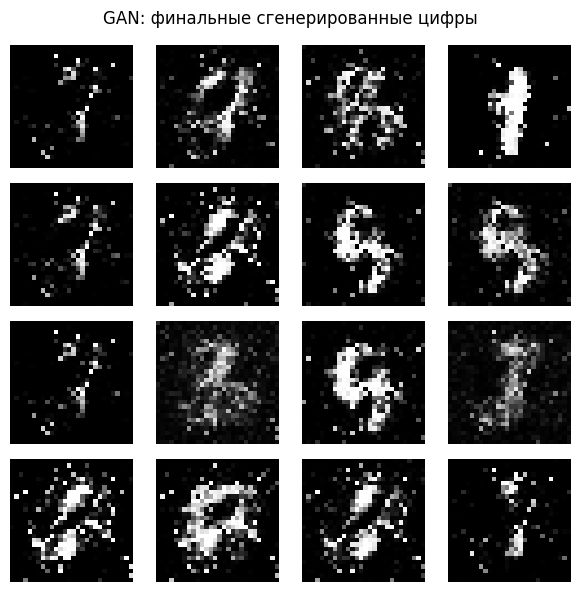

In [15]:
noise = tf.random.normal((16, NOISE_DIM))
gan_generated = generator.predict(noise, verbose=0)
gan_generated = (gan_generated + 1.0) / 2.0

show_images(gan_generated, title="GAN: финальные сгенерированные цифры")

## 4. Сравнение VAE и GAN

| Критерий | VAE | GAN |
|---|---|---|
| Основная идея | encoder-decoder + вероятностное латентное пространство | игра generator против discriminator |
| Обучение | обычно стабильнее | часто нестабильнее |
| Реконструкция входа | есть | обычно нет |
| Генерация | есть | есть |
| Латентное пространство | гладкое и интерпретируемое | не всегда явно интерпретируемое |
| Качество картинок | часто более размытое | может быть более резким |

Для учебной демонстрации полезно увидеть оба подхода:

- VAE показывает связь автоэнкодеров и вероятностного моделирования;
- GAN показывает идею состязательного обучения.

In [16]:
summary = pd.DataFrame(
    [
        {
            "model": "VAE",
            "main_loss": "reconstruction + KL",
            "latent_dim": LATENT_DIM,
            "can_reconstruct": True,
            "can_generate": True,
        },
        {
            "model": "GAN",
            "main_loss": "adversarial BCE",
            "latent_dim": NOISE_DIM,
            "can_reconstruct": False,
            "can_generate": True,
        },
    ]
)

summary

,model,main_loss,latent_dim,can_reconstruct,can_generate
0,VAE,reconstruction + KL,2,True,True
1,GAN,adversarial BCE,64,False,True


## 5. Итоги

В этом блокноте мы:

- загрузили MNIST с Hugging Face;
- подготовили данные для VAE и GAN;
- построили encoder и decoder для VAE;
- реализовали reparameterization trick;
- обучили VAE и получили реконструкции;
- построили generator и discriminator для GAN;
- обучили GAN и получили новые изображения цифр;
- сравнили подходы концептуально.

Главная мысль:

> VAE учится строить упорядоченное латентное пространство, а GAN учится генерировать данные через состязание двух сетей.